# $\color{orange}{\text{C004220A - Statistische fysica}}$ 
# $\color{orange}{\text{Oefeningen: Reeks 5; Oefening 1}}$

This version of the notebook: November 2022 (Jan Ryckebusch)

Model for particles with a short-distance attraction (repulsion or attraction: Massive ($m \ne 0$) particles subject to a Gaussian interaction.

Een re\"{e}el gas heeft een intermoleculaire potentiaal van het type

$u(r_{12}) = \xi \exp \left( - \alpha r_{12}^2 \right) \; , $

waarbij $\alpha > 0$ en $\xi$ constanten zijn en $r_{12}$ de
intermoleculaire separatie voorstelt.



*   (a)Bereken de toestandsvergelijking voor dit reele gas onder omstandigheden van relatief kleine dichtheden.  Veronderstel hierbij dat ${\xi}$ zo klein is dat een reeksontwikkeling in deze parameter mogelijk wordt (hou enkel de laagste-orde termen in deze variabele over in je finale uitdrukkingen).
*  Bepaal de viriaal-coefficient $B_2(T)$. Bestudeer de $B_2(T)$ als een functie van de variabelen $\frac {\xi} {kT}$ en $\frac{1} {\sqrt{\alpha}}$. Wat is de fysische betekenis van deze variabelen? Is the teken en de grootte van $B_2 \left( \frac {\xi} {kT} , \frac{1} {\sqrt{\alpha}} \right) $ in de lijn van de fysische verwachtingen? Verklaar je antwoord. 

 Two relevant parameters in the problem:


1.  $\frac{ \xi} {k T} $ (dimensionless): $\xi$ is the strength of the interaction
2.   $\frac{1} {\sqrt{\alpha}} $ with dimension length: is the effective range of the interaction

This problem illustrates the use of the module numpy and and the use of matplotlib for creating **countour plots**.




In [ ]:
# Importeer numpy en matplotlib
import numpy as np   # numerical python: very fast computing
import matplotlib.pyplot as plt # matplotlib: nice & quick figures

# tweak the parameters of the plots ...
# nothing essential, makes things look nicer ...
 
params = {'legend.fontsize' : 20,
          'axes.linewidth'  : 2.5,
          'axes.labelsize'  : 20,
          'lines.linewidth' : 2, 
          'xtick.major.width' : 3,
          'xtick.major.size'  : 12,
          'ytick.major.width' : 3,
          'ytick.major.size'  : 12,
          'xtick.major.pad'  : 10,
          'xtick.minor.width' : 2,
          'xtick.minor.size'  : 6,
          'ytick.minor.width' : 2,
          'ytick.minor.size'  : 6,
          'xtick.labelsize'    : 18,
          'ytick.labelsize'    : 18 }
plt.rcParams.update(params)


Definieer lijsten met waarden die de variabelen $x = \frac{1}{\sqrt{\alpha}}$ en $y = \frac{\xi}{kT}$ kunnen aannemen en definieer hiermee een grid van alle mogelijke combinaties $(x,y)$.

In [ ]:
# x = 1./\sqrt{\alpha} : a positive number
# y = \xi / k T : can be a positive (attraction) 
#                 or a negative number (repulsion)
x = np.arange(0.1, 3.+0.1, 0.1)
y = np.arange(-3., 3.+0.1, 0.1)
# 
# np.meshgrid is very useful to evaluate functions on a grid
xx, yy = np.meshgrid(x, y, sparse=True)

Bereken de functie $B_2(T)$ voor alle combinaties $(x,y)$.

Voor  voor kleine waarden van $\xi$ hebben we voor $B_2(T)$:

$
	B_2(T) \approx \frac {\xi } {k T} \frac { \pi ^ {3 \over 2} } { 2 \alpha ^ {3 \over 2}} \; .
$

De algemene uitdrukking voor $B_2(T)$ (geldig voor alle waarden van $\xi$) wordt gegeven door:
$
	 B_2(T) = - \frac{1}{2} I_2 = - \frac{1}{2} \int d\vec{r}_{12} \left[ e^{-\beta \xi e^{-\alpha r_{12}^2}} - 1\right] = - \frac{4 \pi}{2} \int_{0} ^ {+\infty} dr_{12} r_{12} ^ {2} \left[ e^{-\beta \xi e^{-\alpha r_{12}^2}} - 1\right] \; .
$ 




In [ ]:
# B_2(T) = y * pi **3/2 /2. * x **1/3
#B2T=np.multiply(np.power(np.pi/2.,3./2.)*yy,np.power(xx,3.))
B2T=np.multiply(np.power(np.pi,3./2.)*yy/2.,np.power(xx,3.)) # expressie voor kleine waarde van \xi

Plot de viriaalcoëfficiënt $B_2(T)$ in functie van $x$ en $y$.

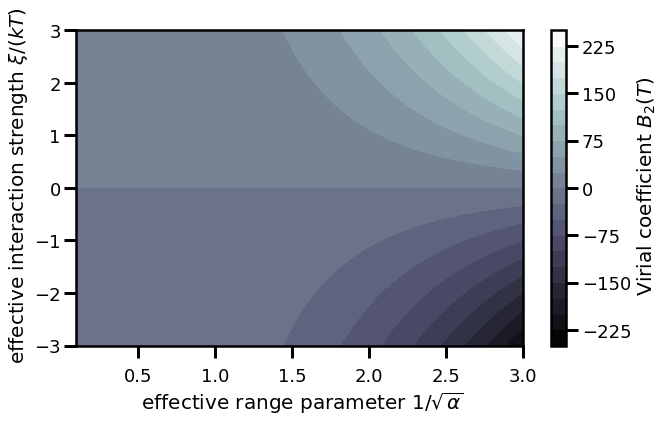

In [ ]:
# essential things for contour plotting
#z = np.sin(xx**2 + yy**2) / (xx**2 + yy**2)
#CS=plt.contourf(x,y,z,10,cmap=plt.cm.bone)

#
# The contour plot
# Fig: the B_2(T) versus x and y (
fig1=plt.figure(figsize=(10,6))
fig1.subplots_adjust(bottom=0.15) # create space for x-axis label
CS1=plt.contourf(x,y,B2T,20,cmap=plt.cm.bone) # plt.cm.inferno 
cbar1=plt.colorbar(CS1) # colorbar receives information from contourf
cbar1.ax.set_ylabel(r' Virial coefficient $B_2(T)$')
plt.xlabel(r' effective range parameter $ 1/ \sqrt{\alpha}$')
plt.ylabel(r' effective interaction strength $\xi / (k T )$')
fig1.savefig('Reeks5OefB2T.png')